In [1]:
import bw2data, bw2io
import bw2calc
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import colormaps
import numpy as np
import pandas as pd
import xarray as xr
plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10')

### read in the two sets of dpGWP prepared: previous default dpGWP one same folder here as `GWP_output_allyears.xlsx`, then a new set of dpGWP w/h fixed static AGWP[CO2] under `../AGWPCO2_fixed_IPCCAR6/dpGWP_CO2CH4N2O_output_fixed_AGWPCO2.xlsx`

In [2]:
file1 = '../AGWPCO2_fixed_IPCCAR6/dpGWP_CO2CH4N2O_output_fixed_AGWPCO2.xlsx'   
file2 = 'GWP_output_allyears.xlsx'   
df1 = pd.read_excel(file1)
df2 = pd.read_excel(file2)

In [3]:
### some clean up needed , df1 -> fixed CO2 (dashed line) df2 -> dpCO2 (solid line)
df1_clean = df1.copy()
df1_clean['SSP'] = df1_clean['SSP'].ffill()
df1_clean['ModelYear'] = df1_clean['ModelYear'].ffill()

df2_clean = df2.loc[:, ~df2.columns.str.startswith('Unnamed')].copy()
df2_clean['SSP'] = df2_clean['SSP'].ffill()
df2_clean['ModelYear'] = df2_clean['ModelYear'].ffill()

### two appraoch of pGWP100

In [ ]:
df1_clean.head()

In [ ]:
df2_clean.head()

In [ ]:
df1_clean[df1_clean['Year'] == 20]

In [ ]:
df1_clean[df1_clean['Year'] == 100]

In [ ]:
df2_clean[df2_clean['Year'] == 100]

### plot by MY/SSP and compare the two sets of dpGWP::  now adding GWP[CO2]

/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_1933/4164951651.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_fixed   = float(y1.query("Year==@year")["CH4_GWP"])
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_1933/4164951651.py:62: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_dynamic = float(y2.query("Year==@year")["CH4_GWP"])


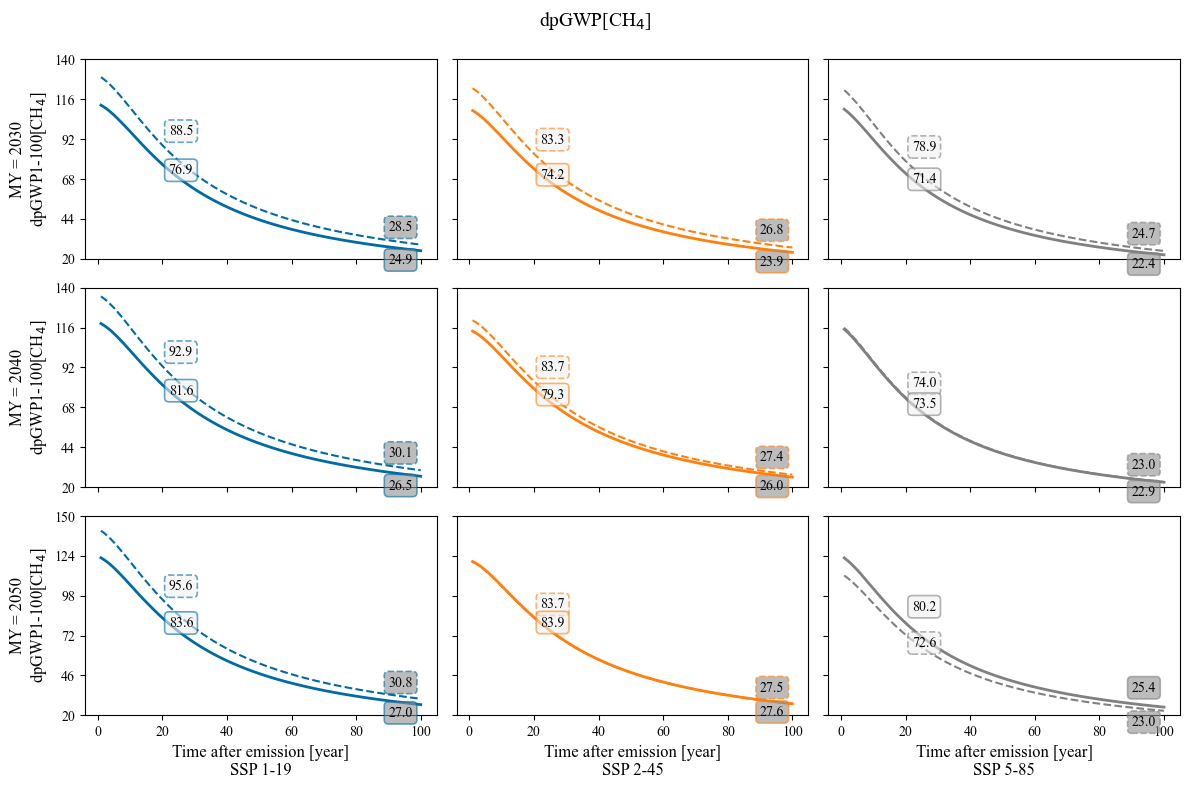

In [14]:
## CH4, now with annotatoin for GWP20/100 values 
fig, axs = plt.subplots(3, 3, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.35, wspace=0.25)

model_years = [2030, 2040, 2050]
ssp_map = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}
colors = {'1-19': '#006BA4', '2-45': '#FF800E', '5-85': 'gray'}
#plt.rcParams['axes.prop_cycle'].by_key()['color'] blue: #006BA4  orange: #FF800E

# annotation box colors
light_gray = "#f0f0f0"  # for GWP20
dark_gray  = "#919090"  # for GWP100  dark gray


for i, my in enumerate(model_years):
    # Compute per-row max Y for dynamic scaling
    max_y = 0
    for ssp1, ssp2 in ssp_map.items():
        y1_max = df1_clean.query("SSP == @ssp1 and ModelYear == @my and Year != 0")["CH4_GWP"].max()
        y2_max = df2_clean.query("SSP == @ssp2 and ModelYear == @my and Year != 0")["CH4_GWP"].max()
        max_y = max(max_y, y1_max, y2_max)
    y_limit = round((max_y + 10) / 10) * 10  # round up to nearest 10

    for j, (ssp1, ssp2) in enumerate(ssp_map.items()):
        ax = axs[i, j]

        # filter for current MY/SSP, excluding Year == 0
        y1 = df1_clean.query("SSP == @ssp1 and ModelYear == @my and Year != 0")
        y2 = df2_clean.query("SSP == @ssp2 and ModelYear == @my and Year != 0")

        # dpGWP with dp CO2 (solid)
        ax.plot(
            y2["Year"], y2["CH4_GWP"],
            label='dpAGWP[CH$_4$] / dpAGWP[CO$_2$]', color=colors[ssp2], linewidth=2
        )

        # dpGWP with fixed CO2(dashed)
        ax.plot(
            y1["Year"], y1["CH4_GWP"],
            label='dpAGWP[CH$_4$] / fixed AGWP[CO$_2$]', linestyle='--', color=colors[ssp2], linewidth=1.5
        )

        ax.set_ylim(20, y_limit)
        ax.set_yticks(np.linspace(20, y_limit, 6))

        # x / y labels 
        # x-label for bottom row
        if i == 2:
            ax.set_xlabel("Time after emission [year]\nSSP " + ssp2, fontsize = 12)
        if j == 0:
            ax.set_ylabel(f'MY = {my}\ndpGWP1-100[CH$_4$]', fontsize = 12)
        #if i == 0 and j == 0:
        #    ax.legend()
        if j > 0:
            ax.set_ylabel(None)
            ax.tick_params(labelleft=False)  


        # --- annotations at Year=20 and Year=100 ---
        for year in (20, 100):
            v_fixed   = float(y1.query("Year==@year")["CH4_GWP"])
            v_dynamic = float(y2.query("Year==@year")["CH4_GWP"])
            # default offsets, for all SSP/MY the dashed line above solid line 
            if year == 20:
                xoff = year + 2
                facecolor = light_gray
                # normal vertical spacing
                yoff_fixed   = v_fixed + 6
                yoff_dynamic = v_dynamic - 6
            else:
                xoff = 90
                facecolor = dark_gray
                # normal spacing
                yoff_fixed   = v_fixed + 8
                yoff_dynamic = v_dynamic - 8

            # special case: bottom‐right panel (i=2,j=2), for SSP585/MY2050, reversed pattern
            if i == 2 and j == 2:
                # swap vertical order and increase gap
                if year == 20:
                    yoff_fixed   = v_fixed - 8
                    yoff_dynamic = v_dynamic + 8
                else:  # year==100
                    yoff_fixed   = v_fixed - 10
                    yoff_dynamic = v_dynamic + 10

            
            # fixed CO2 box (dashed border)
            ax.annotate(
                f"{v_fixed:.1f}",
                xy=(year, v_fixed),
                xytext=(xoff, yoff_fixed),
                textcoords='data',
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor=facecolor,
                    edgecolor=colors[ssp2],
                    linestyle="--",
                    linewidth=1.2,
                    alpha=0.6
                )
            )

            # dp CO2 box (solid border)
            ax.annotate(
                f"{v_dynamic:.1f}",
                xy=(year, v_dynamic),
                xytext=(xoff, yoff_dynamic),
                textcoords='data',
                #color='white' if year==100 else 'black',  # if too dark gray 
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor=facecolor,
                    edgecolor=colors[ssp2],
                    linestyle="-",
                    linewidth=1.2,
                    alpha=0.6
                )
            )


"""
# only legend for N2O as the last subplot in ms

# legend for annotation
patch20  = Patch(facecolor=light_gray,  linestyle="--", label="dpGWP20")
patch100 = Patch(facecolor=dark_gray,   linestyle="-",  label="dpGWP100")
fig.legend(
    handles=[patch20, patch100],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    framealpha=1,
    fontsize=11
)

# legend for the line‐style methods
h_method_dyn = Line2D([0], [0],
                      color="black", linestyle="-",
                      label=r"$dpGWP_{\mathrm{dp\!-\!CO_2}}\, $[kg CO$_2$ SSP$_{[x]}$MY$_{[t]}$ eq.]")

h_method_fix = Line2D([0], [0],
                      color="black", linestyle="--",
                      label=r"$dpGWP_{\mathrm{fixed\!-\!CO_2}} $[kg CO$_2$ 2019 eq.]")

fig.legend(
    handles=[h_method_dyn, h_method_fix],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),  # push it below the other legend
    ncol=2,
    framealpha=1,
    fontsize=12
)
"""


plt.suptitle(r'dpGWP[CH$_4$]', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('output_plot/new_JUL_final/GWP1-100_CH4_Compare_dpGWP.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()


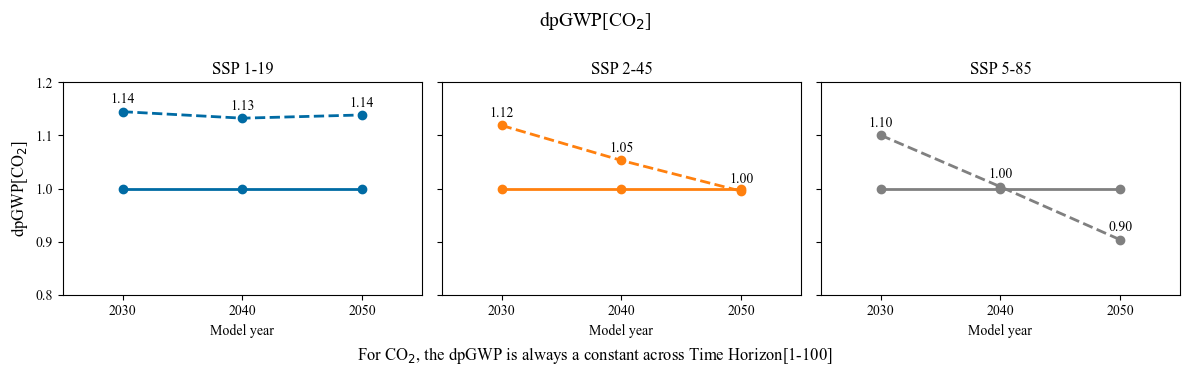

In [11]:
# new CO2 figure: one row, three subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
ssp_map     = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}
model_years = [2030, 2040, 2050]
colors      = {'1-19': '#006BA4', '2-45': '#FF800E', '5-85': 'gray'}

for ax, (ssp1, ssp2) in zip(axs, ssp_map.items()):
    dyn_vals   = []
    fixed_vals = []
    for my in model_years:
        dyn = df2_clean.query(
            "SSP == @ssp2 and ModelYear == @my and Year == 100"
        )["CO2_GWP"].iloc[0]
        fix = df1_clean.query(
            "SSP == @ssp1 and ModelYear == @my and Year == 100"
        )["CO2_GWP"].iloc[0]
        dyn_vals.append(dyn)
        fixed_vals.append(fix)

    #  dp (solid) with circle markers
    ax.plot(model_years, dyn_vals,
            '-o', color=colors[ssp2], lw=2,
            label="dpAGWP[CO$_2$] / dpAGWP[CO$_2$]")

    # fixed (dashed) with circle markers
    ax.plot(model_years, fixed_vals,
            '--o', color=colors[ssp2], lw=2,
            label="dpAGWP[CO$_2$] / fixed AGWP[CO$_2$]") 

    # .1f  for the fixed‐AGWP points, maybe .2f? 
    for x, y in zip(model_years, fixed_vals):
        ax.text(x, y + 0.01, f"{y:.2f}",
                ha='center', va='bottom', fontsize=10)

    # Formatting
    ax.set_title(f"SSP {ssp2}", fontsize=12)
    ax.set_xlabel("Model year", fontsize=10)
    ax.set_xlim(2025, 2055)
    ax.set_xticks(model_years)
    ax.set_ylim(0.8, 1.2)
    ax.set_yticks(np.arange(0.8, 1.25, 0.1))

# shared y‐axis label and legend
axs[0].set_ylabel("dpGWP[CO$_2$]", fontsize=12)
#axs[0].legend(loc="lower left", fontsize=12)


"""
from matplotlib.lines import Line2D
# build two “method” handles
h_method_dyn = Line2D([0], [0],
                      color="black", linestyle="-",
                      lw=2,
                      label=r"$dpGWP_{\mathrm{dp\!-\!CO_2}}\, $[kg CO$_2$ SSP$_{[x]}$MY$_{[t]}$ eq.]")
h_method_fix = Line2D([0], [0],
                      color="black", linestyle="--",
                      lw=2,
                      label=r"$dpGWP_{\mathrm{fixed\!-\!CO_2}} $[kg CO$_2$ 2019 eq.]")


# now a single legend, with a little subtitle
fig.legend(
    handles=[h_method_dyn, h_method_fix],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.23),     # tweak to slide it down
    ncol=2,
    framealpha=1,
    fontsize=12,
    title=(
       r"For CO$_2$, the dpGWP is always a constant across Time Horizon[1-100] and = 1 under $dpGWP_{\mathrm{dynSSP}}\,$ "  # <-- first line of legend
    ),
    title_fontsize=12,
)
"""

fig.text(
    0.5, -0.02,  
    r"For CO$_2$, the dpGWP is always a constant across Time Horizon[1-100]", 
    ha='center',
    fontsize=12
)


plt.suptitle(
    r"dpGWP[CO$_2$]" , fontsize=14  #: dpAGWP[CO$_2$] AND fixed AGWP[CO$_2$] (dashed) vs. dpAGWP[CO$_2$] AND dpAGWP[CO$_2$] (solid)
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('output_plot/new_JUL_final/GWP1-100_CO2_Compare_dpGWP.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()



/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_1933/3551821273.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_fixed   = float(fixed_df.query("Year == @year")["N2O_GWP"])
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_1933/3551821273.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_dynamic = float(dynamic_df.query("Year == @year")["N2O_GWP"])


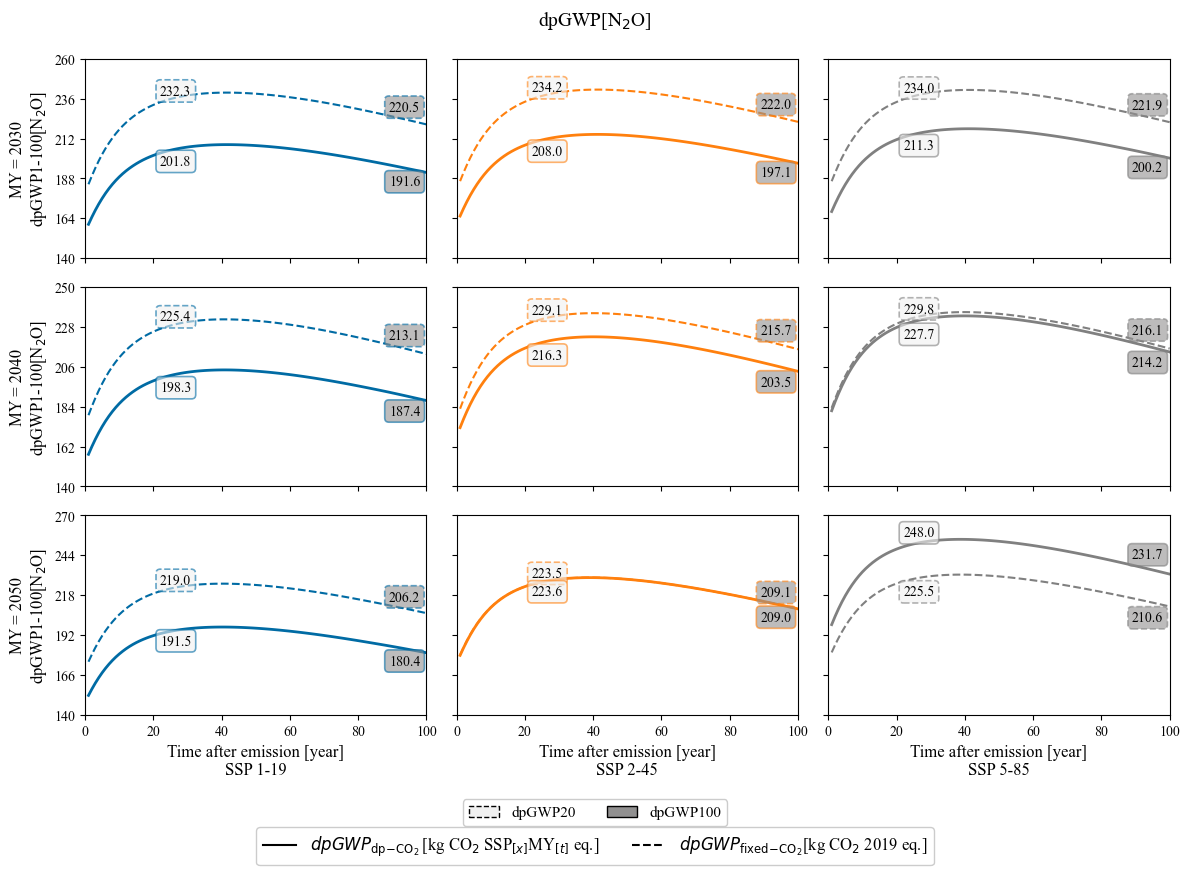

In [12]:

# Annotation box colors
light_gray = "#f0f0f0"   # for GWP20
dark_gray  = "#919090"   # for GWP100

# Model years and SSP mapping
model_years = [2030, 2040, 2050]
ssp_map     = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}
colors      = {'1-19': '#006BA4', '2-45': '#FF800E', '5-85': 'gray'}

fig, axs = plt.subplots(3, 3, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.35, wspace=0.25)

for i, my in enumerate(model_years):
    # Compute top of y-axis
    max_y = 0
    for s1, s2 in ssp_map.items():
        m1 = df1_clean.query("SSP == @s1 & ModelYear == @my & Year != 0")["N2O_GWP"].max()
        m2 = df2_clean.query("SSP == @s2 & ModelYear == @my & Year != 0")["N2O_GWP"].max()
        max_y = max(max_y, m1, m2)
    y_limit = int(np.ceil((max_y + 10)/10))*10

    for j, (ssp1, ssp2) in enumerate(ssp_map.items()):
        ax = axs[i, j]

        # Filter out Year=0
        fixed_df   = df1_clean.query("SSP == @ssp1 & ModelYear == @my & Year != 0")
        dynamic_df = df2_clean.query("SSP == @ssp2 & ModelYear == @my & Year != 0")

        # dp (solid) and fixed (dashed)
        ax.plot(dynamic_df["Year"], dynamic_df["N2O_GWP"],
                color=colors[ssp2], linewidth=2,
                label='dpAGWP[CH$_4$] / dpAGWP[CO$_2$]')
        ax.plot(fixed_df["Year"], fixed_df["N2O_GWP"],
                linestyle='--', color=colors[ssp2], linewidth=1.5,
                label='dpAGWP[CH$_4$] / fixed AGWP[CO$_2$]')

        # limits & ticks
        ax.set_xlim(0, 100)
        ax.set_xticks([0,20,40,60,80,100])
        ax.set_ylim(140, y_limit)
        ax.set_yticks(np.linspace(140, y_limit, 6))

        # labels
        if j == 0:
            ax.set_ylabel(f"MY = {my}\ndpGWP1-100[N$_2$O]", fontsize = 12)
        else:
            ax.tick_params(labelleft=False)

        if i == 2:
            ax.set_xlabel("Time after emission [year]\nSSP " + ssp2, fontsize = 12)

        # legend only on the first subplot
        #if i == 0 and j == 0:
        #    ax.legend(fontsize=11)

        # annotations at Year=20 and Year=100 (no arrows)
        for year in (20, 100):
            v_fixed   = float(fixed_df.query("Year == @year")["N2O_GWP"])
            v_dynamic = float(dynamic_df.query("Year == @year")["N2O_GWP"])

            # Default offsets
            if year == 20:
                xoff = year + 2
                yoff_fixed   = v_fixed + 6
                yoff_dynamic = v_dynamic - 6
                fill = light_gray
            else:
                xoff = 89    # a bit left than CH4
                yoff_fixed   = v_fixed + 8
                yoff_dynamic = v_dynamic - 8
                fill = dark_gray

            # special case for bottom-right (SSP5-85, MY2050)
            if i == 2 and j == 2:
                if year == 20:
                    yoff_fixed   = v_fixed - 8
                    yoff_dynamic = v_dynamic + 8
                else:
                    yoff_fixed   = v_fixed - 10
                    yoff_dynamic = v_dynamic + 10

            # fixed‐AGWP box (dashed outline)
            ax.annotate(
                f"{v_fixed:.1f}",
                xy=(year, v_fixed),
                xytext=(xoff, yoff_fixed),
                textcoords='data',
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor=fill,
                    edgecolor=colors[ssp2],
                    linestyle="--",
                    linewidth=1.2,
                    alpha=0.6
                )
            )

            # dp box (solid outline)
            ax.annotate(
                f"{v_dynamic:.1f}",
                xy=(year, v_dynamic),
                xytext=(xoff, yoff_dynamic),
                textcoords='data',
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor=fill,
                    edgecolor=colors[ssp2],
                    linestyle="-",
                    linewidth=1.2,
                    alpha=0.6
                )
            )

# legend for GWP20 / GWP100 annotation boxes
patch20  = Patch(facecolor=light_gray, edgecolor="black", linestyle="--", label="dpGWP20")
patch100 = Patch(facecolor=dark_gray,  edgecolor="black", linestyle="-",  label="dpGWP100")
fig.legend(
    handles=[patch20, patch100],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    framealpha=1,
    fontsize=11
)


from matplotlib.lines import Line2D
# legend for the line‐style methods
h_method_dyn = Line2D([0], [0],
                      color="black", linestyle="-",
                      label=r"$dpGWP_{\mathrm{dp\!-\!CO_2}}\, $[kg CO$_2$ SSP$_{[x]}$MY$_{[t]}$ eq.]")

h_method_fix = Line2D([0], [0],
                      color="black", linestyle="--",
                      label=r"$dpGWP_{\mathrm{fixed\!-\!CO_2}} $[kg CO$_2$ 2019 eq.]")

fig.legend(
    handles=[h_method_dyn, h_method_fix],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),  # push it below the other legend
    ncol=2,
    framealpha=1,
    fontsize=12
)



plt.suptitle(
    r"dpGWP[N$_2$O]", #: solid = dynamic AGWP vs. dashed = fixed AGW
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('output_plot/new_JUL_final/GWP1-100_N2O_Compare_dpGWP.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()


### just GWP20 & 100, now adding CO2, new layout 2*3 

In [9]:
# fix the col naming: DF1 SSP codes (e.g., 'ssp119') to DF2 style (e.g., '1-19')
ssp_map = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}
df1_clean["SSP"] = df1_clean["SSP"].replace(ssp_map)

# same name GWP20 and GWP100 after SSP rename, only MY = 2030/40/50
def extract_pgwp(df, gas, horizon, model_years=[2030, 2040, 2050]):
    return (
        df[
            (df['Year'] == horizon) &
            (df['ModelYear'].isin(model_years))
        ][['SSP', 'ModelYear', f'{gas}_GWP']]
        .rename(columns={f'{gas}_GWP': f'GWP{horizon}'})
    )

#  CH4 and N2O data from both GWP sets
ch4_20_s1 = extract_pgwp(df1_clean, 'CH4', 20)
ch4_100_s1 = extract_pgwp(df1_clean, 'CH4', 100)
ch4_20_s2 = extract_pgwp(df2_clean, 'CH4', 20)
ch4_100_s2 = extract_pgwp(df2_clean, 'CH4', 100)

n2o_20_s1 = extract_pgwp(df1_clean, 'N2O', 20)
n2o_100_s1 = extract_pgwp(df1_clean, 'N2O', 100)
n2o_20_s2 = extract_pgwp(df2_clean, 'N2O', 20)
n2o_100_s2 = extract_pgwp(df2_clean, 'N2O', 100)

### adding CO2, only GWP100 needed, as GWP20 == GWP100 for both approach: 
co2_20_s1 = extract_pgwp(df1_clean, 'CO2', 20)
co2_100_s1 = extract_pgwp(df1_clean, 'CO2', 100)
co2_20_s2 = extract_pgwp(df2_clean, 'CO2', 20)
co2_100_s2 = extract_pgwp(df2_clean, 'CO2', 100)


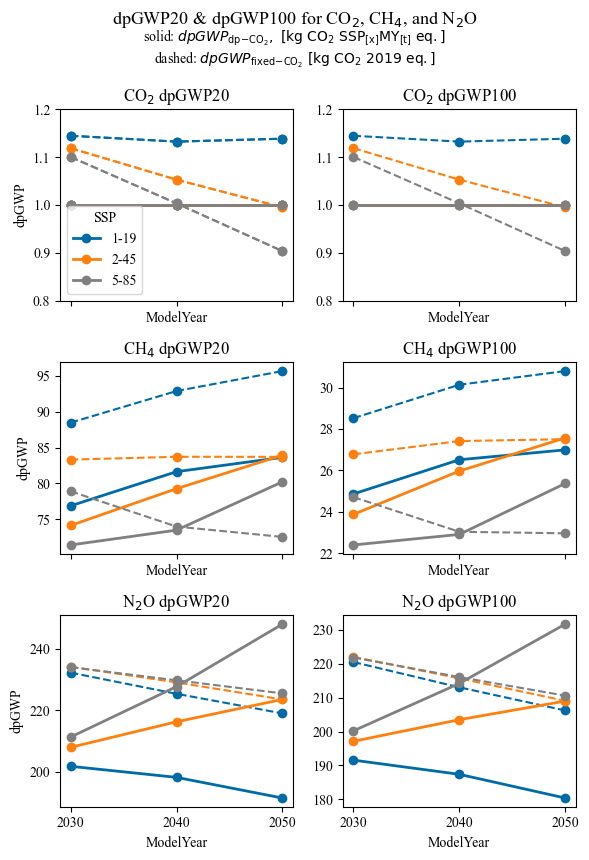

In [26]:
fig, axs = plt.subplots(3, 2, figsize=(6, 9), sharex=True)
axs = axs.reshape(3, 2)
colors = {'1-19': '#006BA4', '2-45': '#FF800E', '5-85': 'gray'}
# --- CO2 (shared y) ---
for label, group2 in co2_20_s2.groupby("SSP"):
    group1 = co2_20_s1[co2_20_s1["SSP"] == label]
    axs[0, 0].plot(group2['ModelYear'], group2['GWP20'], color=colors[label], marker='o', linewidth=2)
    axs[0, 0].plot(group1['ModelYear'], group1['GWP20'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)

for label, group2 in co2_100_s2.groupby("SSP"):
    group1 = co2_100_s1[co2_100_s1["SSP"] == label]
    axs[0, 1].plot(group2['ModelYear'], group2['GWP100'], color=colors[label], marker='o', linewidth=2)
    axs[0, 1].plot(group1['ModelYear'], group1['GWP100'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)
axs[0, 0].set_ylim(0.8, 1.2)
axs[0, 1].set_ylim(0.8, 1.2)


# --- CH4 ---
for label, group2 in ch4_20_s2.groupby("SSP"):
    group1 = ch4_20_s1[ch4_20_s1["SSP"] == label]
    axs[1, 0].plot(group2['ModelYear'], group2['GWP20'], color=colors[label], marker='o', linewidth=2)
    axs[1, 0].plot(group1['ModelYear'], group1['GWP20'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)

for label, group2 in ch4_100_s2.groupby("SSP"):
    group1 = ch4_100_s1[ch4_100_s1["SSP"] == label]
    axs[1, 1].plot(group2['ModelYear'], group2['GWP100'], color=colors[label], marker='o', linewidth=2)
    axs[1, 1].plot(group1['ModelYear'], group1['GWP100'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)

# --- N2O ---
for label, group2 in n2o_20_s2.groupby("SSP"):
    group1 = n2o_20_s1[n2o_20_s1["SSP"] == label]
    axs[2, 0].plot(group2['ModelYear'], group2['GWP20'], color=colors[label], marker='o', linewidth=2)
    axs[2, 0].plot(group1['ModelYear'], group1['GWP20'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)

for label, group2 in n2o_100_s2.groupby("SSP"):
    group1 = n2o_100_s1[n2o_100_s1["SSP"] == label]
    axs[2, 1].plot(group2['ModelYear'], group2['GWP100'], color=colors[label], marker='o', linewidth=2)
    axs[2, 1].plot(group1['ModelYear'], group1['GWP100'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)

titles = [
    r'CO$_2$ dpGWP20', r'CO$_2$ dpGWP100',
    r'CH$_4$ dpGWP20', r'CH$_4$ dpGWP100',
    r'N$_2$O dpGWP20', r'N$_2$O dpGWP100',
]
for ax, title in zip(axs.flat, titles):
    ax.set_title(title, fontsize=12)
    ax.set_xticks([2030, 2040, 2050])
    ax.set_xlabel("ModelYear")

# --- legend and labels ---
handles = []  # store Line2D objects for legend
for label, group2 in co2_20_s2.groupby("SSP"):
    group1 = co2_20_s1[co2_20_s1["SSP"] == label]
    line1, = axs[0, 0].plot(group2['ModelYear'], group2['GWP20'], color=colors[label], marker='o', linewidth=2, label=label)
    axs[0, 0].plot(group1['ModelYear'], group1['GWP20'], color=colors[label], linestyle='--', marker='o', linewidth=1.5)
    handles.append(line1)  # collect just once for each SSP
axs[0, 0].legend(handles=handles, title="SSP", fontsize=10)

axs[0, 0].set_ylabel("dpGWP")
axs[1, 0].set_ylabel("dpGWP")
axs[2, 0].set_ylabel("dpGWP")



plt.suptitle(r'dpGWP20 & dpGWP100 for CO$_2$, CH$_4$, and N$_2$O', fontsize=13)

# subtitle (manually placed below suptitle)
fig.text(
    0.5, 0.92,  # Adjust the vertical position as needed
    r'solid: $dpGWP_{\mathrm{dp\!-\!CO_2}},\ \mathrm{[kg\ CO_2\ SSP_{[x]}MY_{[t]}\ eq.]}$' + '\n' +
    r'dashed: $dpGWP_{\mathrm{fixed\!-\!CO_2}}\ \mathrm{[kg\ CO_2\ 2019\ eq.]}$',
    ha='center',
    fontsize=10
)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('output_plot/new_JUL_final/GWP20-100_CO2_N2O_CH4_compare_twosets_dpGWP_grid.jpg', dpi=300)
plt.show()